## Logistic Regression

In this notebook, we'll walk step-by-step through performing logistic regression using the Titanic dataset. We'll cover each of the following steps clearly and thoroughly:

1. Loading and inspecting the dataset.
2. Preprocessing: Handling missing values and encoding categorical data.
3. Splitting the data into training and testing sets.
4. Training a logistic regression model.
5. Evaluating the model's performance.
6. Checking assumptions for logistic regression.
7. Interpreting the model's results clearly.

### **Step 1: Load and Inspect the Data**
We'll use the Titanic dataset, a popular dataset for predicting passenger survival based on various features.

In [4]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Load Titanic dataset in seaborn
df = sns.load_dataset('titanic')

# Inspect the dataset
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


## **Step 2: Preprocess the Data**
Before training our model, we must prepare the dataset. This step involves two key processes:

*2.1 Handle Missing Values*
Logistic regression requires datasets without missing values, so we remove rows with missing data in important columns (age, embarked).

*2.2 Encode Categorical Variables*
Machine learning algorithms require numerical inputs. Therefore, categorical variables (sex, embarked) must be converted into numeric form using one-hot encoding.

- Why encoding?
    - Converts categorical labels into numeric values that the model can interpret.
    - Avoids misinterpretation of categorical variables as numeric variables (e.g., treating "male" as numerically greater or less than "female").

In [ ]:
# Handling missing values
df.dropna(subset=['age'], inplace=True)

# Encoding categorical variables
df = pd.get_dummies(df, columns=['sex'], drop_first=True) # Use drop_first = True to avoid "dummy trap"

# Define features and target
features = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']
X = df[features]
y = df['survived']

# Preview the cleaned dataset
print(X.head())
print(y.head())

   pclass   age  sibsp  parch     fare  sex_male
0       3  22.0      1      0   7.2500      True
1       1  38.0      1      0  71.2833     False
2       3  26.0      0      0   7.9250     False
3       1  35.0      1      0  53.1000     False
4       3  35.0      0      0   8.0500      True
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


In [10]:

X.info() #Shows us which variables have missing values 

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    714 non-null    int64  
 1   age       714 non-null    float64
 2   sibsp     714 non-null    int64  
 3   parch     714 non-null    int64  
 4   fare      714 non-null    float64
 5   sex_male  714 non-null    bool   
dtypes: bool(1), float64(2), int64(3)
memory usage: 34.2 KB


## **Step 3: Split the Data**
We divide our dataset into two subsets:
- *Training Set*: To build our logistic regression model.
- *Testing Set*: To evaluate the performance of our model.

In [11]:
from sklearn.model_selection import train_test_split 

# Split dataset into training and testing subsets

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.2, 
                                                    random_state = 42)

## **Step 4: Train the Logistic Regression Model**
We'll now build and train our logistic regression model using the training data.

In [12]:
from sklearn.linear_model import LogisticRegression 

# Initialize and train logistic regression model

model = LogisticRegression() #Note: the model only wants numerical values --> we need to convert categorical variables into numeric variables
model.fit(X_train, y_train)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## **Step 5: Evaluate the Model**
To understand how well our model predicts survival, we use the following evaluation metrics:
- *Accuracy*: Proportion of correct predictions.
- *Confusion Matrix*: Breakdown of predictions (True positives, True negatives, False positives, False negatives).
- *Classification Report*: Precision, recall, and F1-score.

0.7482517482517482


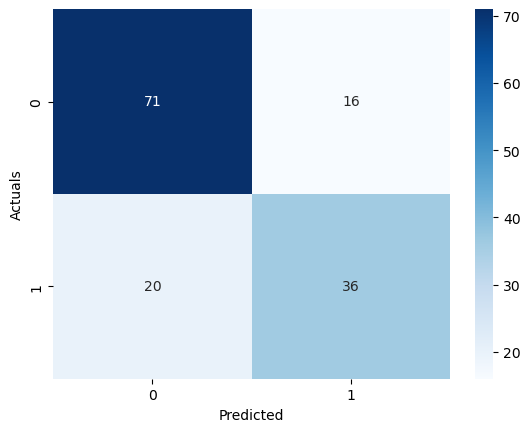

              precision    recall  f1-score   support

           0       0.78      0.82      0.80        87
           1       0.69      0.64      0.67        56

    accuracy                           0.75       143
   macro avg       0.74      0.73      0.73       143
weighted avg       0.75      0.75      0.75       143



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)


# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt= "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actuals")
plt.show() ###Shows the model is 75% accurate. 

# Display classification report
print(classification_report(y_test, y_pred))
#F1 scores show us that our model is better at predicting those who didn't surive 


## **Step 6: Examining and Interpreting the Model**
After training our logistic regression model, let's examine the coefficients to understand their meaning in more detail.
- Coefficients in logistic regression represent the effect of each feature on the log-odds of the target (survival in this case).
- Positive coefficients increase the odds of the outcome (survival).
- Negative coefficients decrease the odds of the outcome (survival).
- The magnitude of coefficients shows the strength of each feature's influence.

### 6.1 Interpreting Coefficients
After training our logistic regression model, let's examine the coefficients to understand their meaning in more detail.
- Coefficients in logistic regression represent the effect of each feature on the log-odds of the target (survival in this case).
- Positive coefficients increase the odds of the outcome (survival).
- Negative coefficients decrease the odds of the outcome (survival).
- The magnitude of coefficients shows the strength of each feature's influence.

Output:
- Coefficient Interpretation:
    - Positive coefficients: Increase the log-odds (and thus probability) of survival.
    - Negative coefficients: Decrease the log-odds (and thus probability) of survival.



| Feature      | Coefficient | Impact on Survival Probability                      | Explanation                                                    |
|--------------|-------------|-----------------------------------------------------|----------------------------------------------------------------|
| `pclass`     | -1.21       | Decreases                                           | Lower passenger classes (higher numeric values) decrease survival odds.            |
| `age`        | -0.04       | Slight negative impact                              | Older passengers have slightly lower odds of survival.         |
| `sibsp`      | -0.35       | Negative impact                                     | Having more siblings/spouses aboard decreases survival odds.   |
| `parch`      | -0.05       | Slight negative impact                              | Having more parents/children aboard slightly reduces odds.     |
| `fare`       | 0.002      | Very slight positive impact                         | Paying higher fares slightly increases survival odds.          |
| `sex_male`   | -2.61       | Strong negative impact                              | Being male greatly decreases the probability of survival.      |
| **Intercept**| 5.47        | Baseline log-odds                                   | Baseline survival odds for females with lowest-class, fare, and minimal age. |


In [ ]:
# Extract coefficients and intercept


# Display coefficients


### 6.2 Understanding the `predict_proba` Function
Logistic regression outputs probabilities between 0 and 1, indicating the likelihood of belonging to a specific class.
- The function predict_proba() returns two columns:
    - Probability of class 0 (not survived).
    - Probability of class 1 (survived).
- Output:
    - Each row gives the probability of not surviving (first column) and surviving (second column).
    - Useful for making informed decisions based on probabilities rather than just binary predictions.

In [ ]:
# Get predicted probabilities for the test set

# Display probabilities for first 5 test observations
